# Advanced: Ny-Ålesund Radiation

In this notebook, we'll simulate radiation at Ny-Ålesund (Svalbard, 78.9°N) using real radiosonde profiles retrieved from the IGRA database. This demonstrates the complete workflow: fetching atmospheric profiles, converting them to libRadtran format, and running thermal and solar simulations.

In [1]:
import pyradtran
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

# Suppress verbose output from pyradtran
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# ── Solar config ─────────────────────────────────────────────────────────────
cfg_solar = load_config()
cfg_solar.simulation_defaults.rte_solver           = "disort"
cfg_solar.simulation_defaults.mol_abs_param        = "reptran per_nm"
cfg_solar.simulation_defaults.source               = "solar"
cfg_solar.simulation_defaults.wavelength_nm        = [400, 3200]
cfg_solar.simulation_defaults.integrate_wavelength = True
cfg_solar.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg_solar.execution.max_workers                    = 16
cfg_solar.execution.cleanup_temp_files             = False
solar_config_path = Path("config/cloud_solar.yaml")
cfg_solar.to_yaml(solar_config_path)

# ── Thermal config ────────────────────────────────────────────────────────────
cfg_thermal = load_config()
cfg_thermal.simulation_defaults.rte_solver           = "disort"
cfg_thermal.simulation_defaults.mol_abs_param        = "reptran medium"
cfg_thermal.simulation_defaults.source               = "thermal"
cfg_thermal.simulation_defaults.wavelength_nm        = [4500, 42000]
cfg_thermal.simulation_defaults.integrate_wavelength = True
cfg_thermal.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg_thermal.execution.max_workers                    = 16
cfg_thermal.execution.cleanup_temp_files             = False
thermal_config_path = Path("config/cloud_thermal.yaml")
cfg_thermal.to_yaml(thermal_config_path)

print(f"Solar config:   {solar_config_path}")
print(f"Thermal config: {thermal_config_path}")

# ── Input dataset ─────────────────────────────────────────────────────────────
N_timesteps = 10
lat, lon = 78.925, 11.922222   # Ny-Ålesund, Svalbard

ds = xr.Dataset(
    coords={
        'time':      pd.date_range('2024-06-07T00:00:00', periods=N_timesteps, freq='1h'),
        'latitude':  ('time', [lat] * N_timesteps),
        'longitude': ('time', [lon] * N_timesteps),
        'altitude':  ('altitude', [0.0]),
    },
    data_vars={
        'surface_temperature': ('time', [275.15] * N_timesteps),  # Kelvin
    }
)

ds

2026-04-18 18:02:14,587 - pyradtran.config - INFO - Configuration written to config/cloud_solar.yaml


2026-04-18 18:02:14,590 - pyradtran.config - INFO - Configuration written to config/cloud_thermal.yaml


Solar config:   config/cloud_solar.yaml
Thermal config: config/cloud_thermal.yaml


<xarray.Dataset> Size: 328B
Dimensions:              (time: 10, altitude: 1)
Coordinates:
  * time                 (time) datetime64[ns] 80B 2024-06-07 ... 2024-06-07T...
    latitude             (time) float64 80B 78.92 78.92 78.92 ... 78.92 78.92
    longitude            (time) float64 80B 11.92 11.92 11.92 ... 11.92 11.92
  * altitude             (altitude) float64 8B 0.0
Data variables:
    surface_temperature  (time) float64 80B 275.1 275.1 275.1 ... 275.1 275.1

## Retrieving Radiosonde Data

We use the `RadiosondeAtmosphereGenerator` to fetch the closest IGRA radiosonde sounding to our target location and time, then convert it into a libRadtran-compatible atmosphere file.

In [2]:
from datetime import datetime
from pyradtran.io import RadiosondeAtmosphereGenerator

# Build a libRadtran atmosphere file from the closest IGRA sounding
atm_path = RadiosondeAtmosphereGenerator.create_radiosonde_atmosphere_file(
    time=datetime(2024, 6, 7, 0),
    latitude=lat,
    longitude=lon,
    output_filepath="work/sonde_nya.dat",
)

print(f"Atmosphere file created at: {atm_path}")

# Print the first few lines of the generated atmosphere file to verify
print("\nFirst 10 lines of the generated atmosphere file:")
with open(atm_path, 'r') as f:
    for _ in range(10):
        print(f.readline().strip())

Atmosphere file created at: work/sonde_nya.dat

First 10 lines of the generated atmosphere file:
# Radiosonde atmosphere profile
# BJORNOYA at 2024-06-07 00:00 UTC with distance 521.61 km
# p(hPa)  T(K)  h2o(RH%)
11.64  234.45  0.465
12.23  232.85  0.458
13.33  233.45  0.460
13.61  233.55  0.463
14.17  232.15  0.462
14.43  231.75  0.458
14.79  231.65  0.456


## Running Simulations

Now we run both solar and thermal simulations using the radiosonde atmosphere profile. The `parameter_overrides` argument lets us inject the radiosonde path directly into the configuration.

In [3]:
ds_sim_solar = ds.pyradtran.run(
    config_path=solar_config_path,
    return_dataset=True,
    save_to_file=False,
    parameter_overrides={"radiosonde": str(atm_path) + " H2O RH"},
    show_progress=False,
)

ds_sim_thermal = ds.pyradtran.run(
    config_path=thermal_config_path,
    return_dataset=True,
    save_to_file=False,
    parameter_overrides={"radiosonde": str(atm_path) + " H2O RH"},
    show_progress=False,
)

Running simulations:   0%|          | 0/10 [00:00<?, ?sim/s]

Running simulations:  10%|█         | 1/10 [00:12<01:51, 12.43s/sim]

Running simulations:  10%|█         | 1/10 [00:12<01:51, 12.43s/sim, Success=1, Total=10]

Running simulations:  20%|██        | 2/10 [00:12<00:41,  5.25s/sim, Success=1, Total=10]

Running simulations:  20%|██        | 2/10 [00:12<00:41,  5.25s/sim, Success=2, Total=10]

...

Running simulations:  80%|████████  | 8/10 [00:05<00:00,  2.06sim/s, Success=8, Total=10]

Running simulations:  90%|█████████ | 9/10 [00:05<00:00,  2.18sim/s, Success=8, Total=10]

Running simulations:  90%|█████████ | 9/10 [00:05<00:00,  2.18sim/s, Success=9, Total=10]

Running simulations: 100%|██████████| 10/10 [00:06<00:00,  2.18sim/s, Success=10, Total=10]

Running simulations: 100%|██████████| 10/10 [00:06<00:00,  1.59sim/s, Success=10, Total=10]

## Results

Let's inspect the simulation output and plot the downwelling irradiance for both solar and thermal spectral ranges.

In [4]:
ds_sim_solar

<xarray.Dataset> Size: 808B
Dimensions:   (time: 10, altitude: 1)
Coordinates:
  * time      (time) datetime64[ns] 80B 2024-06-07 ... 2024-06-07T09:00:00
  * altitude  (altitude) int64 8B 0
Data variables:
    zout      (altitude, time) float64 80B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lambda    (altitude, time) float64 80B 400.0 400.0 400.0 ... 400.0 400.0
    sza       (altitude, time) float64 80B 78.01 77.11 75.57 ... 60.05 58.04
    edir      (altitude, time) float64 80B 1.443e+05 1.589e+05 ... 4.724e+05
    eglo      (altitude, time) float64 80B 1.753e+05 1.912e+05 ... 5.267e+05
    edn       (altitude, time) float64 80B 3.096e+04 3.235e+04 ... 5.432e+04
    eup       (altitude, time) float64 80B 1.49e+05 1.626e+05 ... 4.477e+05
    enet      (altitude, time) float64 80B 2.629e+04 2.869e+04 ... 7.901e+04
    albedo    (altitude, time) float64 80B 0.85 0.85 0.85 ... 0.85 0.85 0.85
Attributes:
    point_id:             20240607_000000_78.92_11.92_0
    time:                 2024-06-07T00:00:00
    latitude:             78.925
    longitude:            11.922222
    albedo:               None
    surface_temperature:  None
    surface_type:         None
    altitude:             None
    generated_by:         pyradtran
    pyradtran_version:    unified_system
    generation_date:      2026-04-18T18:04:52.409559

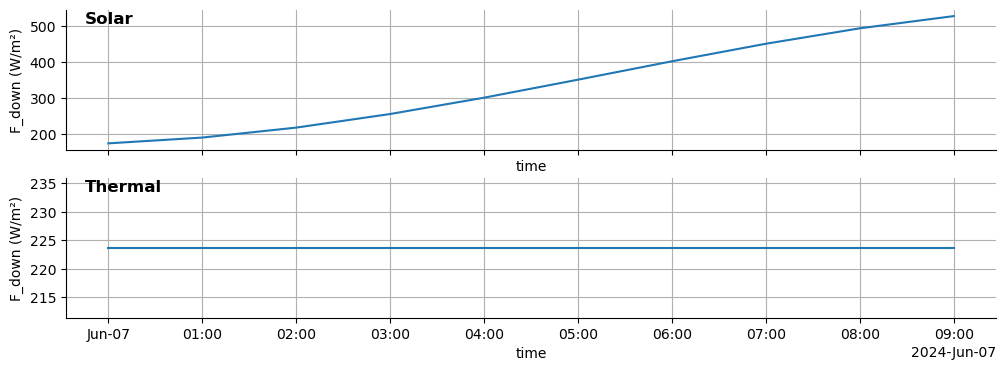

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

(ds_sim_solar.eglo / 1000).plot(ax=ax[0])
(ds_sim_thermal.eglo).plot(ax=ax[1])

texts = ['Solar', 'Thermal']
for a, t in zip(ax, texts):
    a.text(0.02, 0.9, t, transform=a.transAxes, fontsize=12, fontweight='bold')
for a in ax:
    a.set_ylabel('F_down (W/m²)')
    a.grid()
    a.spines[['top', 'right']].set_visible(False)
    a.set_title('')